# Tabular Deep Learning — When GBMs Aren't Enough

## Overview
For decades, gradient-boosted machines (XGBoost, LightGBM) dominated tabular data. Deep learning excels at images and text, but tabular data presents unique challenges: heterogeneous feature types, small datasets, and no spatial/sequential structure to exploit.

Modern tabular DL methods close this gap by treating each feature as a token — enabling attention-based architectures to learn feature interactions.

### What You'll Build
- Feature Tokenizer from scratch (PyTorch)
- Simplified TabNet with attention masks
- FT-Transformer (Feature Tokenizer + Transformer)
- Benchmark: LR vs RF vs GBM vs FT-Transformer

### Why It Matters
TabNet won Kaggle competitions. FT-Transformer matches or beats GBMs on many benchmarks. Understanding *why* matters for choosing the right tool.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
print(f'PyTorch {torch.__version__} | Device: CPU')

PyTorch 2.12.1+cpu | Device: CPU


## 1. Why Tabular DL Is Hard

| Challenge | Images/Text | Tabular |
|-----------|-------------|--------|
| Feature homogeneity | Pixels / tokens — same type | Mix of numerical, categorical, binary |
| Spatial/sequential structure | Yes — convolutions/attention exploit it | No |
| Dataset size | Often millions | Often thousands |
| Inductive bias | Strong (translation invariance, etc.) | None — GBMs exploit tree structure |

**The key insight**: GBMs build axis-aligned splits — they excel at sparse, heterogeneous features. Deep learning needs a way to *represent* each feature before interactions can be learned.

### The Feature Tokenizer Idea
Map each feature $x_j$ to a $d$-dimensional vector (token):
$$
T(x_j) = \begin{cases} W_j \cdot x_j + b_j & \text{numerical} \\ E_j[x_j] & \text{categorical (lookup)} \end{cases}
$$
Then stack all tokens: $\mathbf{T} = [T(x_1), T(x_2), \ldots, T(x_p)] \in \mathbb{R}^{p \times d}$

Now each feature is a vector, and standard Transformer attention can learn cross-feature interactions.

## 2. TabNet Architecture

TabNet (Arik & Pfister, 2021) uses **sequential attention** to select features at each step:

At step $t$, the attentive transformer computes a feature mask:
$$
\mathbf{M}[t] = \text{sparsemax}\left(\mathbf{P}[t] \cdot h(\mathbf{a}[t-1]) \cdot \mathbf{W}_{\text{att}}\right)
$$

where $\mathbf{P}[t]$ is the **prior scale** (penalises reuse of features already selected):
$$
\mathbf{P}[t] = \prod_{\tau=1}^{t-1}(\gamma - \mathbf{M}[\tau]), \quad \mathbf{P}[0] = \mathbf{1}
$$

The total loss adds a **sparsity regularisation** term:
$$
\mathcal{L} = \mathcal{L}_{\text{task}} + \lambda_{s} \sum_{t=1}^{T_{\text{steps}}} \sum_j \frac{-\mathbf{M}[t]_j \log(\mathbf{M}[t]_j + \epsilon)}{T_{\text{steps}}}
$$

## 3. Load & Prepare Data

In [2]:
# Use breast cancer dataset (binary classification, 30 numerical features)
data = load_breast_cancer()
X, y = data.data.astype(np.float32), data.target.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Features: {data.feature_names[:5]} ...')
print(f'Classes: {data.target_names}')

Train: (455, 30), Test: (114, 30)
Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness'] ...
Classes: ['malignant' 'benign']


## 4. From Scratch: Feature Tokenizer + Transformer (FT-Transformer)

In [3]:
class NumericalFeatureTokenizer(nn.Module):
    """Projects each numerical feature x_j → d-dim vector via learnable W_j, b_j."""
    def __init__(self, n_features: int, d_token: int = 64):
        super().__init__()
        # One weight per feature (not shared)
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias   = nn.Parameter(torch.zeros(n_features, d_token))
        nn.init.kaiming_uniform_(self.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, n_features)  →  (B, n_features, d_token)
        return x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)


class FTTransformer(nn.Module):
    """Feature Tokenizer + Transformer for tabular classification."""
    def __init__(self, n_features: int, n_classes: int, d_token: int = 64,
                 n_heads: int = 4, n_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.tokenizer = NumericalFeatureTokenizer(n_features, d_token)
        # CLS token — aggregates information from all features
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, n_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Tokenise features: (B, p) → (B, p, d)
        tokens = self.tokenizer(x)
        # Prepend CLS token: (B, p+1, d)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        # Transformer encoder
        out = self.transformer(tokens)
        # Classification from CLS position
        return self.head(out[:, 0, :])


# Build and inspect model
n_features = X_train.shape[1]
model = FTTransformer(n_features=n_features, n_classes=2, d_token=64, n_heads=4, n_layers=2)
total_params = sum(p.numel() for p in model.parameters())
print(f'FT-Transformer parameters: {total_params:,}')
print(model)

FT-Transformer parameters: 104,130
FTTransformer(
  (tokenizer): NumericalFeatureTokenizer()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)


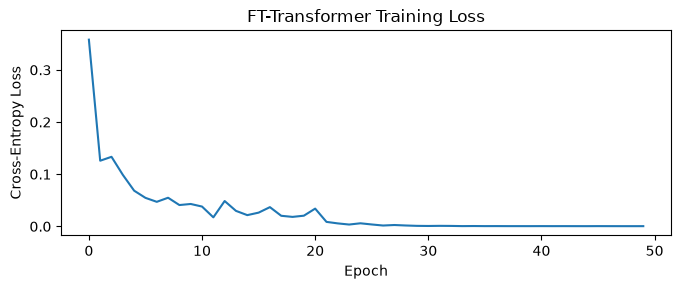

In [4]:
def train_model(model, X_tr, y_tr, epochs=50, lr=1e-3, batch_size=64):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    X_t = torch.tensor(X_tr)
    y_t = torch.tensor(y_tr, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    history = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        history.append(epoch_loss / len(loader))
    return history


history = train_model(model, X_train, y_train, epochs=50)

plt.figure(figsize=(7, 3))
plt.plot(history)
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.title('FT-Transformer Training Loss')
plt.tight_layout(); plt.show()

## 5. From Scratch: Simplified TabNet

In [5]:
class SimplifiedTabNet(nn.Module):
    """Simplified TabNet: 2-step sequential feature selection."""
    def __init__(self, n_features: int, n_classes: int, n_d: int = 32, n_steps: int = 2):
        super().__init__()
        self.n_steps = n_steps
        self.n_features = n_features
        self.n_d = n_d

        # Shared and step-specific fully-connected layers
        self.initial_bn = nn.BatchNorm1d(n_features)
        self.shared_fc  = nn.Linear(n_features, n_d * 2)
        self.step_fcs   = nn.ModuleList([nn.Linear(n_d, n_features) for _ in range(n_steps)])
        self.step_bns   = nn.ModuleList([nn.BatchNorm1d(n_features) for _ in range(n_steps)])
        self.head = nn.Linear(n_d, n_classes)
        self.masks = []  # store for visualisation

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.initial_bn(x)
        prior = torch.ones_like(x)      # P[0] = 1
        complementary = torch.zeros(x.size(0), self.n_d, device=x.device)
        self.masks = []

        for step in range(self.n_steps):
            # Attentive transformer: soft feature selection mask
            h = F.relu(self.step_fcs[step](complementary))
            h = self.step_bns[step](h * prior)
            mask = torch.softmax(h, dim=-1)          # sparsemax in real TabNet
            self.masks.append(mask.detach())

            # Update prior: penalise reused features (γ=1.5 in original)
            prior = prior * (1.5 - mask)

            # Feature transformer
            masked_x = mask * x
            h2 = self.shared_fc(masked_x)
            complementary = complementary + F.relu(h2[:, :self.n_d]) * torch.sigmoid(h2[:, self.n_d:])

        return self.head(complementary)


tabnet = SimplifiedTabNet(n_features=n_features, n_classes=2, n_d=32, n_steps=2)
history_tn = train_model(tabnet, X_train, y_train, epochs=50, lr=2e-3)
print('TabNet training complete')

TabNet training complete


## 6. Benchmark: All Models Compared

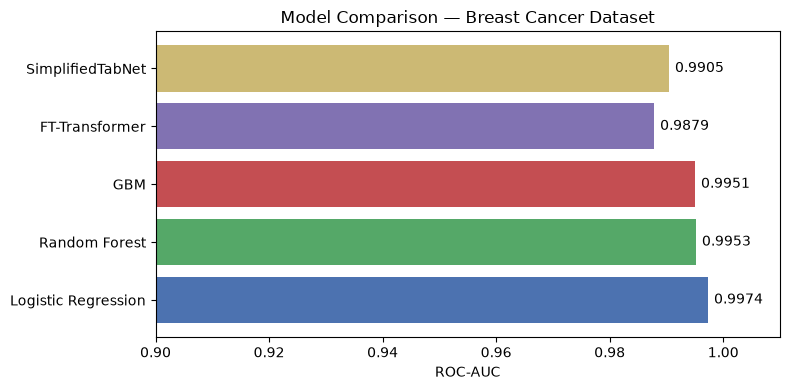

Logistic Regression      : AUC = 0.9974
Random Forest            : AUC = 0.9953
GBM                      : AUC = 0.9951
FT-Transformer           : AUC = 0.9879
SimplifiedTabNet         : AUC = 0.9905


In [6]:
def eval_torch(m, X_t):
    m.eval()
    with torch.no_grad():
        logits = m(torch.tensor(X_t))
        preds = logits.argmax(dim=1).numpy()
        probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    return preds, probs

results = {}

# Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
results['Logistic Regression'] = roc_auc_score(y_test, lr_clf.predict_proba(X_test)[:,1])

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
results['Random Forest'] = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

# Gradient Boosting
gbm = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
results['GBM'] = roc_auc_score(y_test, gbm.predict_proba(X_test)[:,1])

# FT-Transformer
_, ft_probs = eval_torch(model, X_test)
results['FT-Transformer'] = roc_auc_score(y_test, ft_probs)

# SimplifiedTabNet
_, tn_probs = eval_torch(tabnet, X_test)
results['SimplifiedTabNet'] = roc_auc_score(y_test, tn_probs)

fig, ax = plt.subplots(figsize=(8, 4))
models = list(results.keys())
aucs = list(results.values())
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
bars = ax.barh(models, aucs, color=colors)
ax.set_xlabel('ROC-AUC')
ax.set_title('Model Comparison — Breast Cancer Dataset')
ax.set_xlim(0.9, 1.01)
for bar, v in zip(bars, aucs):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center')
plt.tight_layout(); plt.show()

for m, v in results.items():
    print(f'{m:25s}: AUC = {v:.4f}')

## 7. Feature Importance via Attention Masks (TabNet)

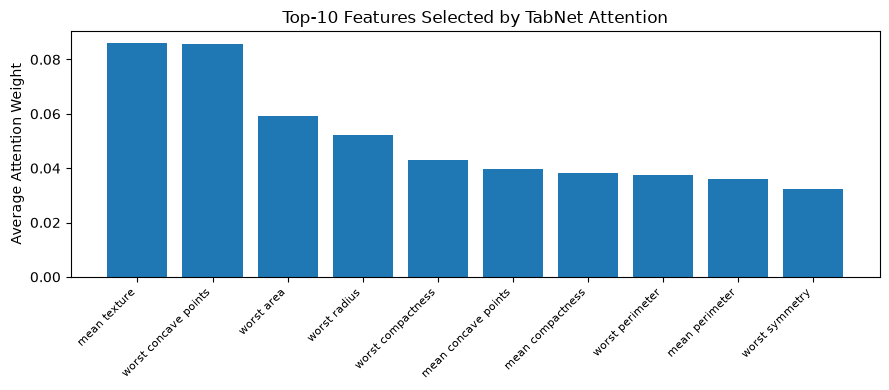

In [7]:
# Run TabNet on test set to extract masks
tabnet.eval()
with torch.no_grad():
    _ = tabnet(torch.tensor(X_test[:50]))

# Average mask across steps and samples
avg_mask = np.mean([m.numpy()[:50] for m in tabnet.masks], axis=0).mean(axis=0)
top_idx = np.argsort(avg_mask)[::-1][:10]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(10), avg_mask[top_idx])
ax.set_xticks(range(10))
ax.set_xticklabels([data.feature_names[i] for i in top_idx], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Average Attention Weight')
ax.set_title('Top-10 Features Selected by TabNet Attention')
plt.tight_layout(); plt.show()

## 8. Entity Embeddings for Categorical Features

Categorical features are the main advantage of embedding-based tabular DL over one-hot encoding:

$$
E_j[\text{category}_i] \in \mathbb{R}^{d_j}, \quad d_j = \min\left(50,\ \lceil \text{cardinality}_j / 2 \rceil\right)
$$

This learns a *geometry* of categories — similar categories end up close in embedding space.

Mixed model accuracy: 0.888


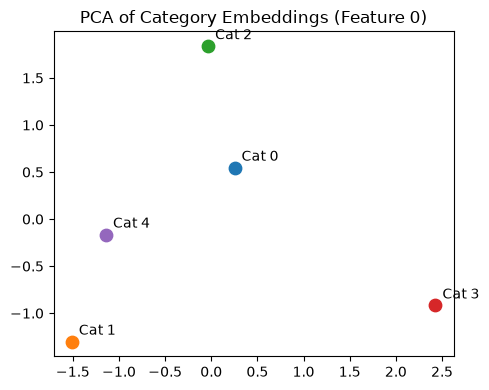

In [8]:
class TabularWithEmbeddings(nn.Module):
    """Handles mixed numerical + categorical features."""
    def __init__(self, cat_dims: list, num_cont: int, n_classes: int, emb_dim: int = 8, hidden: int = 64):
        super().__init__()
        # One embedding per categorical feature
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cats, emb_dim) for n_cats in cat_dims
        ])
        emb_total = len(cat_dims) * emb_dim
        self.bn = nn.BatchNorm1d(emb_total + num_cont)
        self.mlp = nn.Sequential(
            nn.Linear(emb_total + num_cont, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_classes)
        )

    def forward(self, x_cat: torch.Tensor, x_cont: torch.Tensor) -> torch.Tensor:
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_cont], dim=1)
        return self.mlp(self.bn(x))


# Demo with synthetic mixed data
np.random.seed(0)
n = 500
x_cat = torch.randint(0, 5, (n, 3))   # 3 categorical features, 5 categories each
x_cont = torch.randn(n, 4)             # 4 numerical features
y_demo = ((x_cont[:, 0] + x_cat[:, 0].float()) > 0).long()

mixed_model = TabularWithEmbeddings(cat_dims=[5, 5, 5], num_cont=4, n_classes=2, emb_dim=4)
opt = torch.optim.Adam(mixed_model.parameters(), lr=1e-3)
for _ in range(30):
    loss = F.cross_entropy(mixed_model(x_cat, x_cont), y_demo)
    opt.zero_grad(); loss.backward(); opt.step()

mixed_model.eval()
with torch.no_grad():
    acc = (mixed_model(x_cat, x_cont).argmax(1) == y_demo).float().mean()
print(f'Mixed model accuracy: {acc:.3f}')

# Visualise category embeddings for feature 0
emb_weights = mixed_model.embeddings[0].weight.detach().numpy()  # (5, 4)
from sklearn.decomposition import PCA
coords = PCA(n_components=2).fit_transform(emb_weights)
fig, ax = plt.subplots(figsize=(5, 4))
for i, (x2, y2) in enumerate(coords):
    ax.scatter(x2, y2, s=80)
    ax.annotate(f'Cat {i}', (x2, y2), textcoords='offset points', xytext=(5, 5))
ax.set_title('PCA of Category Embeddings (Feature 0)')
plt.tight_layout(); plt.show()

## 9. When to Choose Tabular DL vs GBMs

| Situation | Recommendation |
|-----------|---------------|
| < 1,000 rows | GBM — DL overfits |
| 1k–10k rows | GBM first; try FT-Transformer if GBM plateaus |
| > 100k rows | FT-Transformer often competitive or better |
| High-cardinality categoricals | Tabular DL (embeddings >> one-hot) |
| Need feature importances | TabNet (attention masks) |
| Need fast inference | GBM (tree eval < transformer) |
| Multi-task output | Tabular DL (shared encoder) |
| Requires minimal tuning | GBM |

## 10. Training Tips

1. **Normalise all numerical inputs** (StandardScaler or min-max) — transformers are sensitive to scale
2. **Use AdamW** with weight decay ~1e-4; GBMs require no such care
3. **Cosine LR schedule** — prevents LR being too large late in training
4. **CLS token** for classification (FT-Transformer style) generalises better than mean pooling
5. **Batch size** 256–1024 works best; small batches destabilise BatchNorm in TabNet
6. **Pre-training**: FT-Transformer can be self-supervised pretrained (masked feature prediction) — improves small-data performance

## Additional Learning Resources

| Resource | Link | What It Covers |
|----------|------|----------------|
| **TabNet Paper** (Arik & Pfister 2021) | [arXiv:1908.07442](https://arxiv.org/abs/1908.07442) | Original TabNet with full derivation |
| **Revisiting Deep Learning for Tabular Data** (Gorishniy et al. 2021) | [arXiv:2106.11959](https://arxiv.org/abs/2106.11959) | FT-Transformer + comprehensive benchmark |
| **Why do tree-based models still outperform DL?** (Grinsztajn et al. 2022) | [arXiv:2207.08815](https://arxiv.org/abs/2207.08815) | Honest benchmark; explains when DL loses |
| **pytorch-tabular library** | [github.com/manujosephv/pytorch_tabular](https://github.com/manujosephv/pytorch_tabular) | Production-ready TabNet, FT-Transformer, GANDALF |
| **Entity Embeddings of Categorical Variables** (Guo & Berkhahn) | [arXiv:1604.06737](https://arxiv.org/abs/1604.06737) | The Rossmann competition trick |
| **rtdl library** | [github.com/Yandex-Research/rtdl](https://github.com/Yandex-Research/rtdl) | Yandex's research library for tabular DL |